# Back to Basics: Understanding the Skew Series

Before building any signal or trading logic, we need to understand what we are actually modelling.

This notebook investigates the **raw skew series** produced by the vol model:
- Is it stationary?
- How does it mean-revert (OU dynamics, half-life)?
- What does its distribution look like — is it Gaussian or fat-tailed?
- Are there jumps? Can we decompose it into a diffusion + jump component?

Pipeline runs only to the skew stage. No signal module, no backtest.

In [1]:
from pipeline import Pipeline, MasterRunSpec, DataSpec, VolatilityModelSpec, SkewSpec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cfg = MasterRunSpec(
    data=DataSpec(
        tickers=["XLF", "GS", "JPM", "BAC", "C"],
        start_date="2008-01-01",
        end_date="2026-12-31",
    ),
    model=VolatilityModelSpec(model_kind="surface"),
    skew=SkewSpec(technique="rr_approx", rr_k=0.15, tenor_days=[30, 60, 90]),
)

p = Pipeline(cfg)

/Users/bjorn/Documents/Skóli/Stanford/Skóli/Q2/StatArb/Statistical_Arbitrage_Stanford_MS-E244/project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
loaded   = p.run_load(saved="basics.parquet")
processed = p.run_process(loaded, saved="basics.parquet")
modeled  = p.run_model(processed, saved="basics.parquet")


In [3]:
# Fitlering out data after 2025-12-31 to avoid lookahead bias.

for ticker in cfg.data.tickers:
    modeled.model_by_ticker[ticker] = modeled.model_by_ticker[ticker][modeled.model_by_ticker[ticker]["date"] <= "2015-12-31"]

skew = p.run_skew(modeled)

## Step 1: Raw skew time series

Look at what we are actually modelling before any statistics.

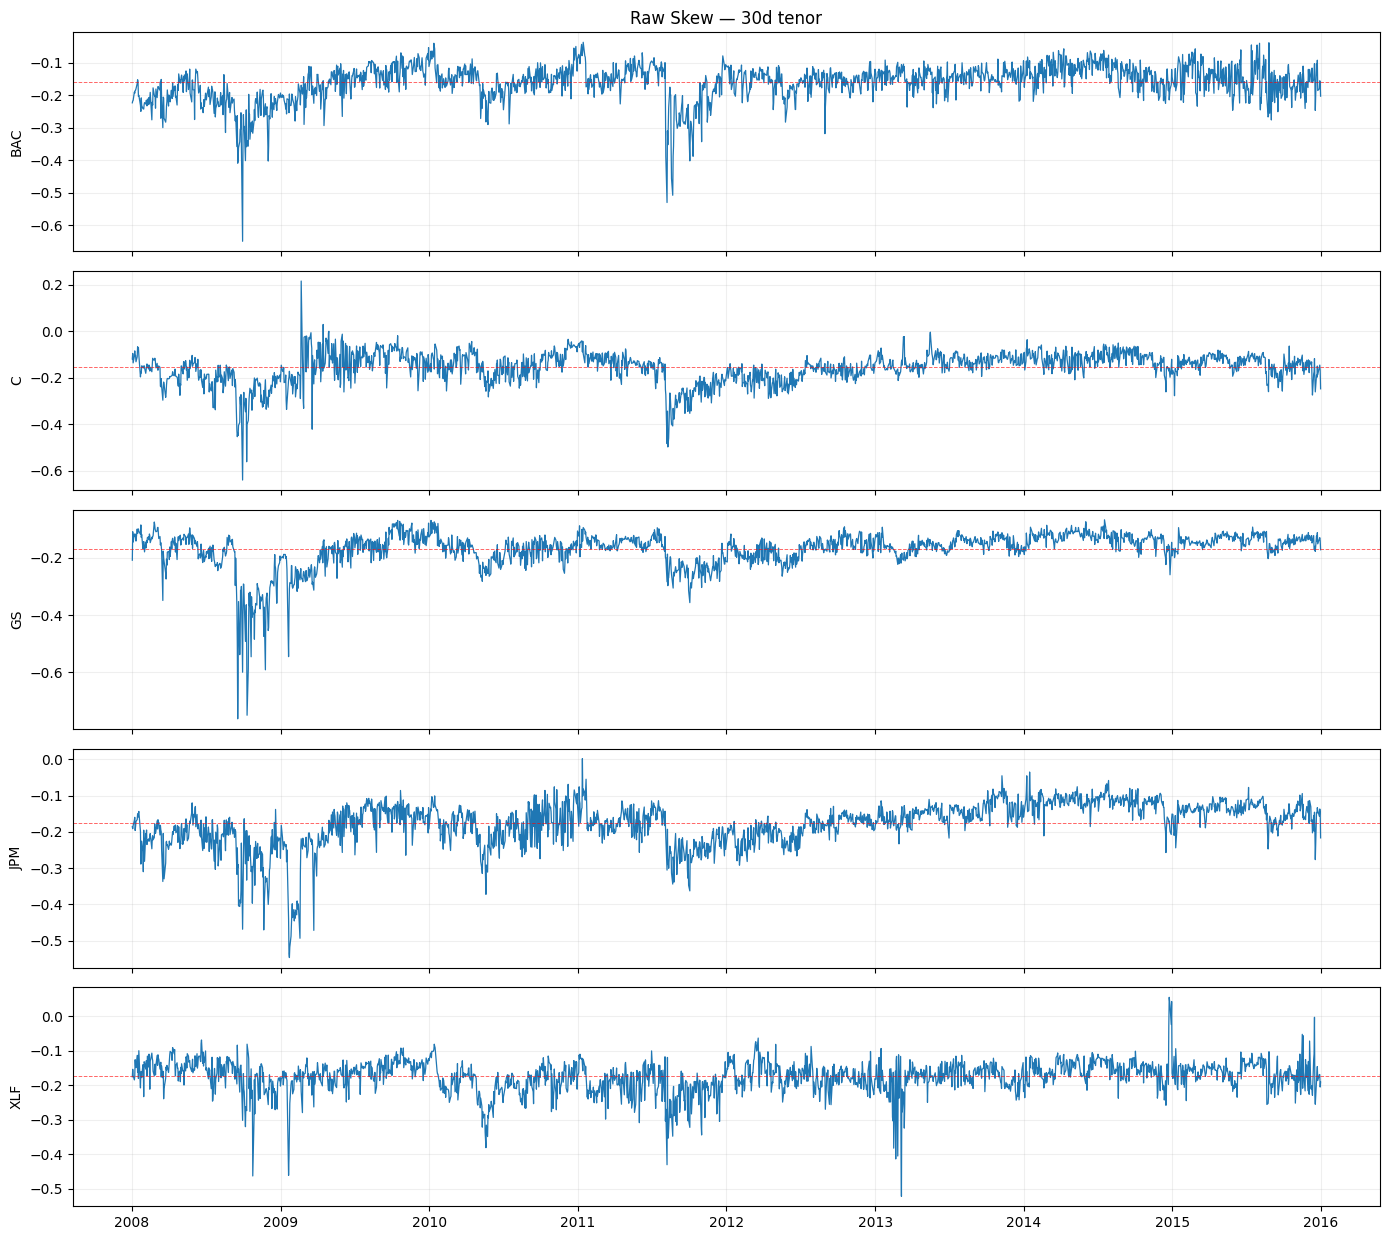

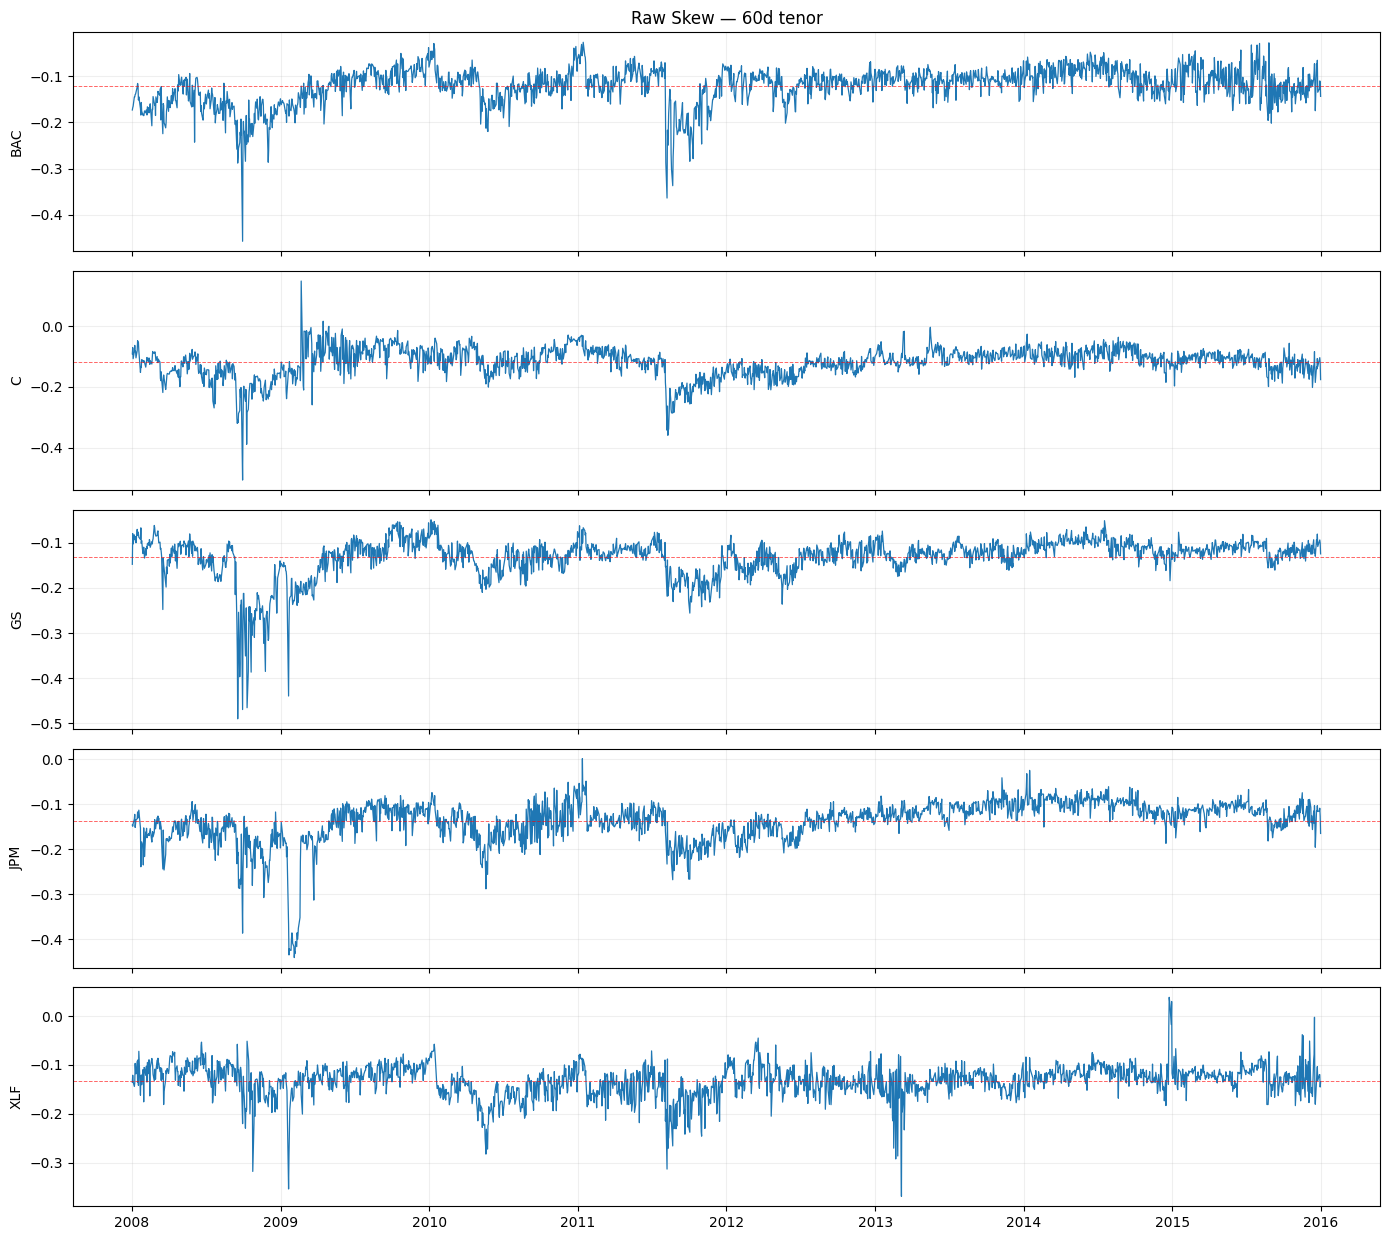

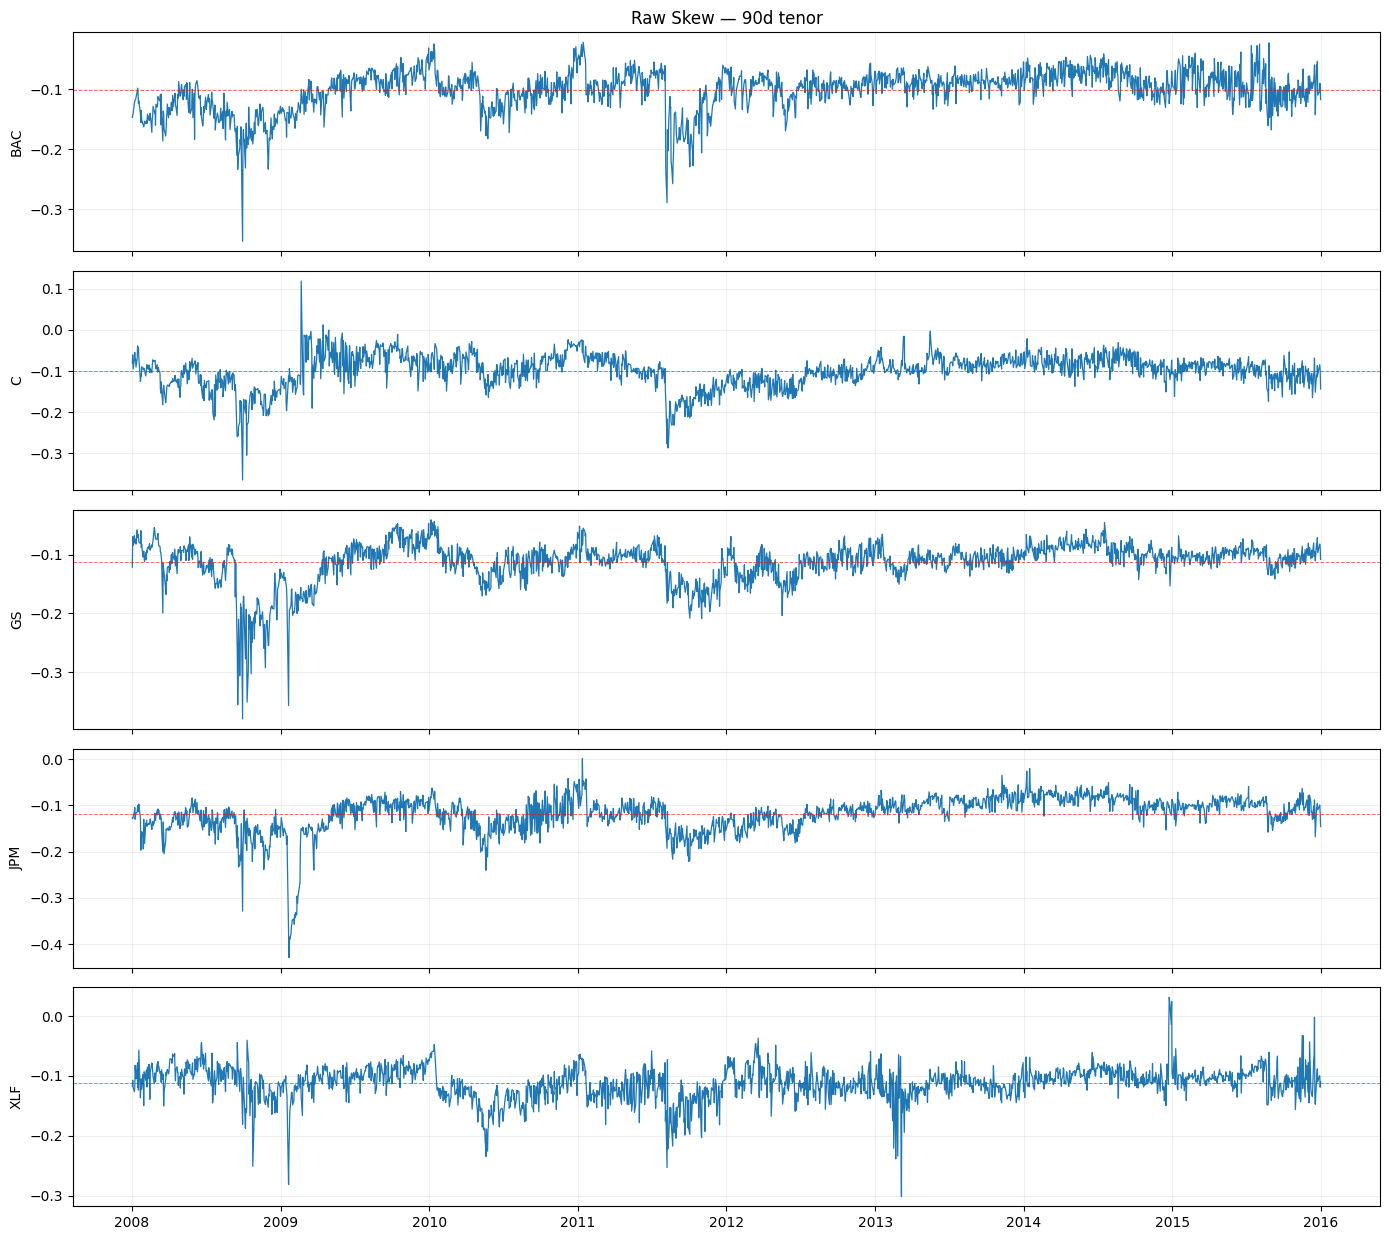

In [4]:
# Stack skew output into a tidy DataFrame
parts = []
for ticker, df in skew.skew_by_ticker.items():
    if df is None or df.empty:
        continue
    x = df.copy()
    x["ticker"] = ticker
    x["date"] = pd.to_datetime(x["date"])
    parts.append(x)
skew_df = pd.concat(parts, ignore_index=True).sort_values(["ticker", "tenor_days", "date"]).reset_index(drop=True)

tenors = sorted(skew_df["tenor_days"].unique()) if "tenor_days" in skew_df.columns else [None]
tickers = sorted(skew_df["ticker"].unique())

# Raw time series per tenor
for td in tenors:
    sub = skew_df[skew_df["tenor_days"] == td] if td is not None else skew_df
    fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 2.5 * len(tickers)), sharex=True)
    if len(tickers) == 1:
        axes = [axes]
    for ax, ticker in zip(axes, tickers):
        g = sub[sub["ticker"] == ticker].sort_values("date")
        ax.plot(g["date"], g["skew"], linewidth=0.9)
        ax.axhline(g["skew"].mean(), color="red", linewidth=0.7, linestyle="--", alpha=0.6)
        ax.set_ylabel(ticker)
        ax.grid(alpha=0.2)
    axes[0].set_title(f"Raw Skew — {td}d tenor" if td else "Raw Skew")
    plt.tight_layout()
    plt.show()

## Step 2: Stationarity

ADF: null = unit root (want p < 0.05 to reject, confirming stationarity).  
KPSS: null = stationary (want p > 0.05 to fail-to-reject, confirming stationarity).  
Hurst exponent: H < 0.5 = mean-reverting, H = 0.5 = random walk, H > 0.5 = trending.

In [5]:
from statsmodels.tsa.stattools import adfuller, kpss
# Remove warning messages
import warnings
warnings.filterwarnings("ignore")

def hurst(series: np.ndarray, max_lag: int = 40) -> float:
    """Hurst exponent via R/S analysis."""
    lags = range(2, min(max_lag, len(series) // 2))
    rs = []
    for lag in lags:
        chunks = [series[i:i+lag] for i in range(0, len(series) - lag, lag)]
        rs_vals = []
        for c in chunks:
            c = c - c.mean()
            cs = np.cumsum(c)
            r = cs.max() - cs.min()
            s = c.std()
            if s > 1e-12:
                rs_vals.append(r / s)
        if rs_vals:
            rs.append(np.mean(rs_vals))
    if len(rs) < 2:
        return np.nan
    log_lags = np.log(list(lags)[:len(rs)])
    log_rs   = np.log(rs)
    h, _ = np.polyfit(log_lags, log_rs, 1)
    return float(h)

print(f"{'ticker':<6} {'tenor':>6}  {'ADF stat':>10} {'ADF p':>8}  {'KPSS stat':>10} {'KPSS p':>8}  {'Hurst':>7}  verdict")
print("-" * 80)
for td in tenors:
    for ticker in tickers:
        sub = skew_df[(skew_df["ticker"] == ticker)]
        if td is not None:
            sub = sub[sub["tenor_days"] == td]
        s = sub.sort_values("date")["skew"].dropna().to_numpy(dtype=np.float64)
        if len(s) < 30:
            continue
        adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
        try:
            kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
        except Exception:
            kpss_stat, kpss_p = np.nan, np.nan
        h = hurst(s)
        stationary = adf_p < 0.05 and kpss_p > 0.05
        mean_rev   = h < 0.45
        verdict = "✓ stationary" if stationary else ("~ borderline" if adf_p < 0.10 else "✗ non-stationary")
        if mean_rev:
            verdict += " | mean-reverting"
        print(f"{ticker:<6} {str(td):>6}  {adf_stat:>10.3f} {adf_p:>8.4f}  {kpss_stat:>10.3f} {kpss_p:>8.4f}  {h:>7.3f}  {verdict}")
    print()

ticker  tenor    ADF stat    ADF p   KPSS stat   KPSS p    Hurst  verdict
--------------------------------------------------------------------------------
BAC        30      -4.998   0.0000       1.454   0.0100    0.773  ~ borderline
C          30      -4.064   0.0011       0.795   0.0100    0.811  ~ borderline
GS         30      -3.690   0.0043       1.492   0.0100    0.832  ~ borderline
JPM        30      -5.692   0.0000       2.855   0.0100    0.823  ~ borderline
XLF        30      -6.649   0.0000       0.625   0.0204    0.794  ~ borderline

BAC        60      -4.760   0.0001       1.693   0.0100    0.785  ~ borderline
C          60      -3.755   0.0034       0.467   0.0491    0.801  ~ borderline
GS         60      -4.131   0.0009       1.117   0.0100    0.817  ~ borderline
JPM        60      -5.561   0.0000       2.332   0.0100    0.813  ~ borderline
XLF        60      -5.294   0.0000       0.624   0.0205    0.781  ~ borderline

BAC        90      -4.574   0.0001       1.834   0.01

## Step 3: Ornstein-Uhlenbeck Fitting

Fit the discrete OU process: X_{t+1} = μ + (1-θ)·X_t + ε  
- θ (speed): how fast it reverts — higher = faster  
- half-life = ln(2) / θ  (trading days)
- σ: daily volatility of the OU noise

ticker  tenor     theta         mu    sigma  half-life (d)
------------------------------------------------------------
BAC        30    0.3000    -0.1607   0.0393            2.3
C          30    0.2569    -0.1559   0.0443            2.7
GS         30    0.1634    -0.1696   0.0345            4.2
JPM        30    0.1940    -0.1759   0.0362            3.6
XLF        30    0.4583    -0.1747   0.0391            1.5

BAC        60    0.2630    -0.1202   0.0269            2.6
C          60    0.2388    -0.1175   0.0312            2.9
GS         60    0.1717    -0.1323   0.0246            4.0
JPM        60    0.1677    -0.1375   0.0262            4.1
XLF        60    0.4435    -0.1325   0.0278            1.6

BAC        90    0.2346    -0.1011   0.0213            3.0
C          90    0.2194    -0.0988   0.0251            3.2
GS         90    0.1697    -0.1131   0.0196            4.1
JPM        90    0.1640    -0.1177   0.0216            4.2
XLF        90    0.4212    -0.1118   0.0226         

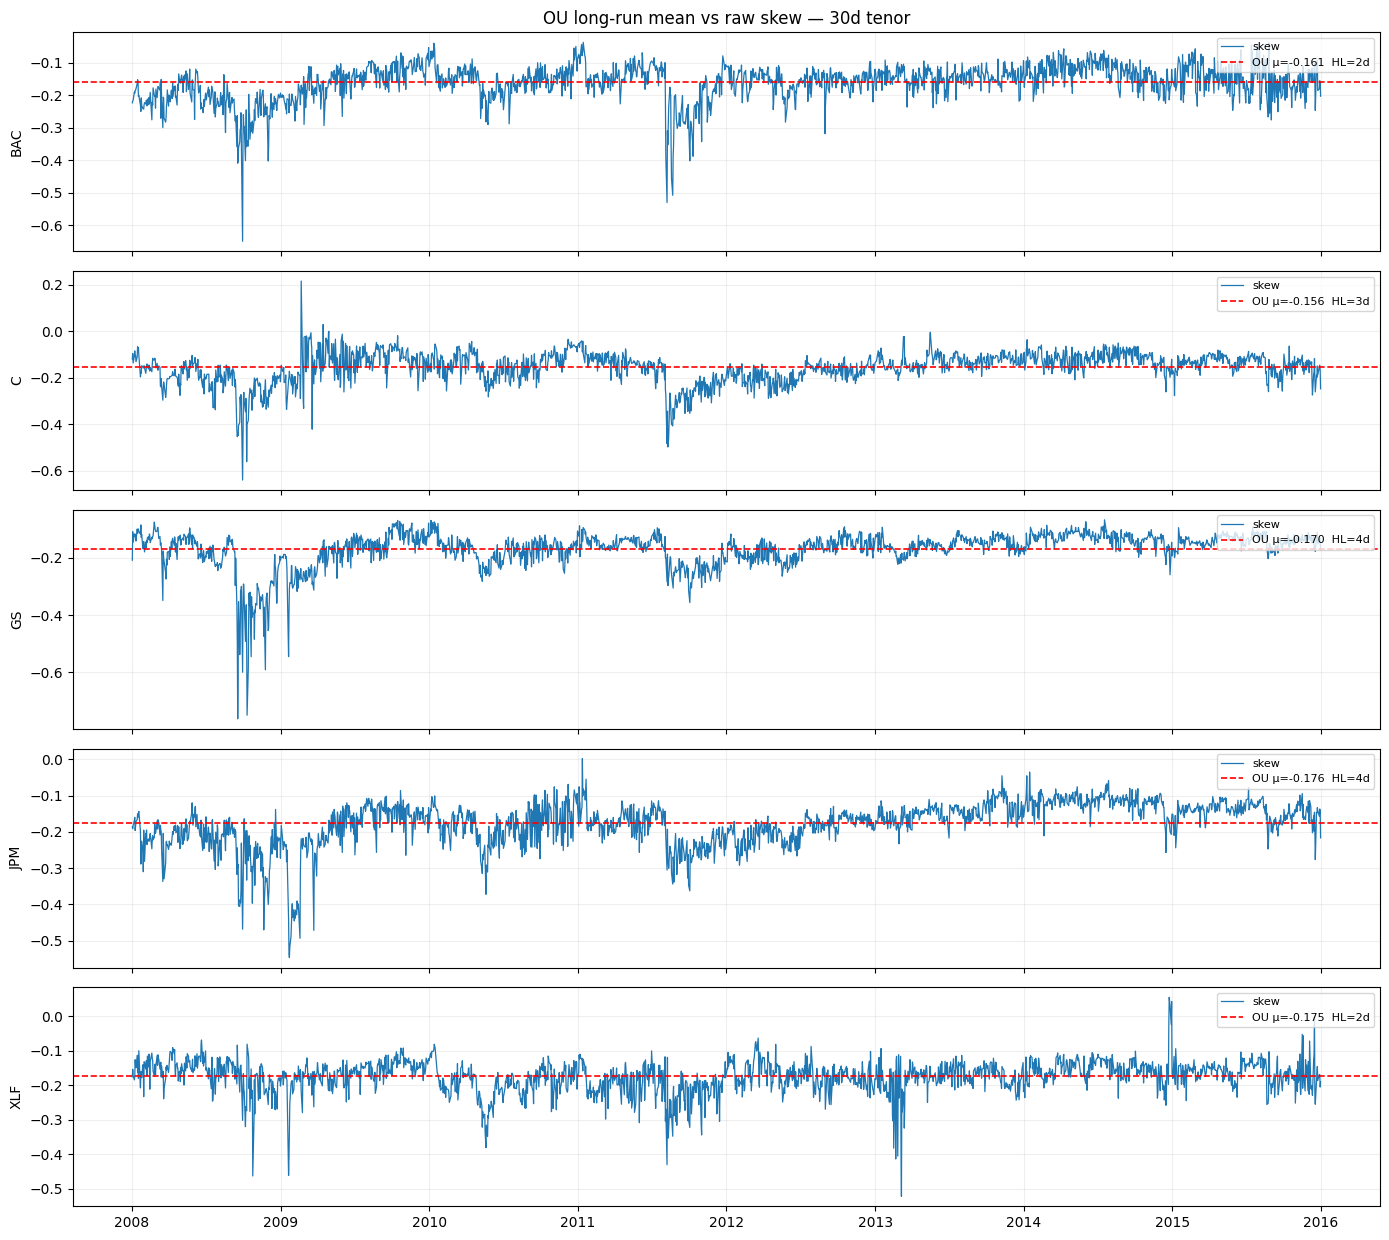

In [6]:
def fit_ou(series: np.ndarray):
    """OLS fit of the discrete OU: ΔX = α + β·X_{t-1} + ε → θ = -β, μ = α/θ."""
    x = series[:-1]
    dx = np.diff(series)
    A = np.column_stack([np.ones(len(x)), x])
    coef, resid, *_ = np.linalg.lstsq(A, dx, rcond=None)
    alpha, beta = coef
    theta = -beta                        # speed of reversion (per day)
    mu    = alpha / theta if abs(theta) > 1e-12 else np.nan
    sigma = float(np.std(dx - A @ coef))
    half_life = np.log(2) / theta if theta > 1e-12 else np.nan
    return {"theta": theta, "mu": mu, "sigma": sigma, "half_life_days": half_life}

print(f"{'ticker':<6} {'tenor':>6}  {'theta':>8} {'mu':>10} {'sigma':>8} {'half-life (d)':>14}")
print("-" * 60)
for td in tenors:
    for ticker in tickers:
        sub = skew_df[skew_df["ticker"] == ticker]
        if td is not None:
            sub = sub[sub["tenor_days"] == td]
        s = sub.sort_values("date")["skew"].dropna().to_numpy(dtype=np.float64)
        if len(s) < 30:
            continue
        r = fit_ou(s)
        print(f"{ticker:<6} {str(td):>6}  {r['theta']:>8.4f} {r['mu']:>10.4f} {r['sigma']:>8.4f} {r['half_life_days']:>14.1f}")
    print()

# Visual: fitted OU mean alongside raw skew (30d)
td_plot = tenors[0]
sub = skew_df[skew_df["tenor_days"] == td_plot] if td_plot else skew_df
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 2.5 * len(tickers)), sharex=True)
if len(tickers) == 1:
    axes = [axes]
for ax, ticker in zip(axes, tickers):
    g = sub[sub["ticker"] == ticker].sort_values("date")
    s = g["skew"].dropna().to_numpy(dtype=np.float64)
    r = fit_ou(s)
    ax.plot(g["date"], g["skew"], linewidth=0.9, label="skew")
    ax.axhline(r["mu"], color="red", linewidth=1.2, linestyle="--", label=f"OU μ={r['mu']:.3f}  HL={r['half_life_days']:.0f}d")
    ax.set_ylabel(ticker)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.2)
axes[0].set_title(f"OU long-run mean vs raw skew — {td_plot}d tenor")
plt.tight_layout()
plt.show()

## Step 4: Distribution of Daily Changes

Are the daily moves Gaussian? Fat-tailed? This tells us whether OU is the right model
or whether we need heavier tails (t-distribution, jump process).

ticker   skew (kurt)  Δskew (kurt)      JB p   t-dist ν  interpretation
--------------------------------------------------------------------------------
BAC             6.46          4.71    0.0000       4.43  heavy tails
C               4.72          9.01    0.0000       3.62  heavy tails
GS             15.63         13.35    0.0000       2.94  heavy tails
JPM             4.60          3.69    0.0000       3.13  heavy tails
XLF             5.77          8.47    0.0000       2.79  heavy tails


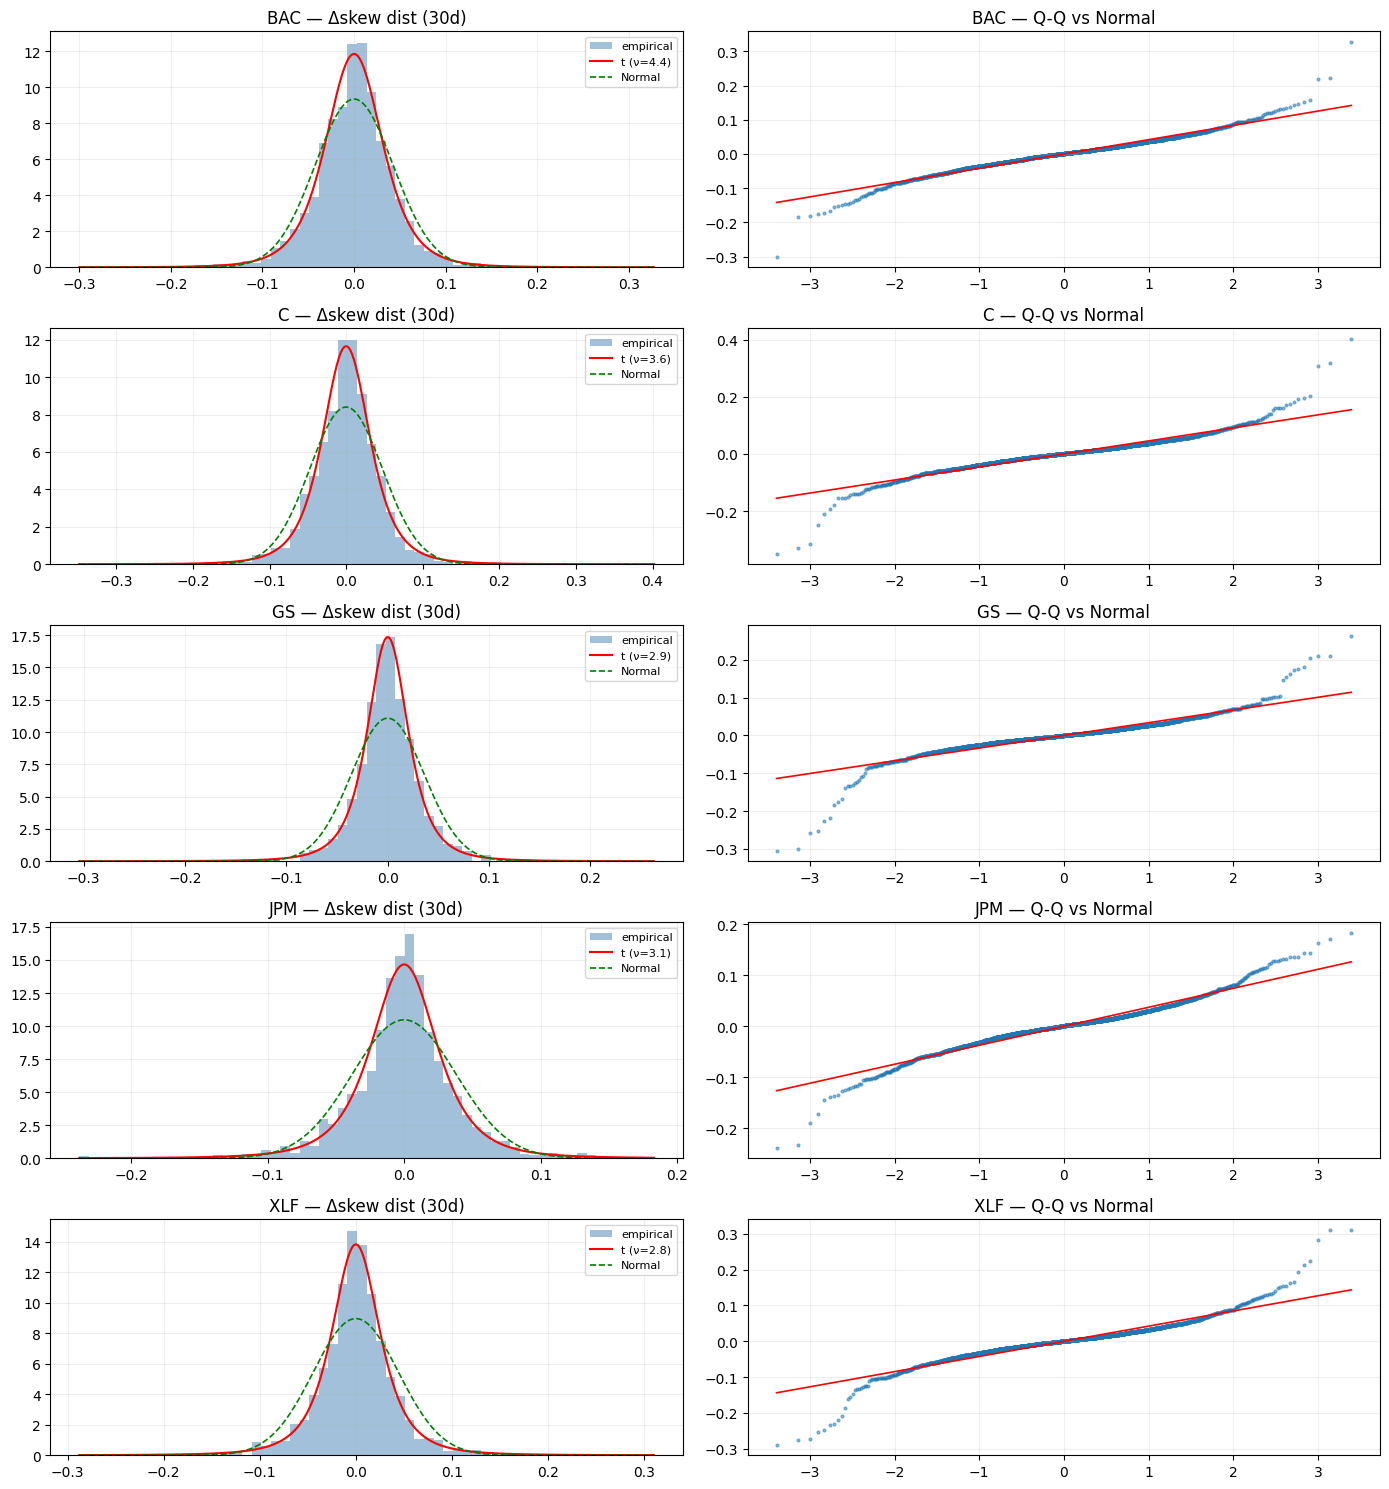

In [7]:
from scipy import stats

td_plot = tenors[0]
sub = skew_df[skew_df["tenor_days"] == td_plot] if td_plot else skew_df

fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 3 * len(tickers)))
if len(tickers) == 1:
    axes = axes[np.newaxis, :]

print(f"{'ticker':<6}  {'skew (kurt)':>12} {'Δskew (kurt)':>13}  {'JB p':>8}  {'t-dist ν':>9}  interpretation")
print("-" * 80)

for i, ticker in enumerate(tickers):
    g = sub[sub["ticker"] == ticker].sort_values("date")
    s  = g["skew"].dropna().to_numpy(dtype=np.float64)
    ds = np.diff(s)

    # Fit Student-t to daily changes
    nu, loc, scale = stats.t.fit(ds, floc=0)
    jb_stat, jb_p  = stats.jarque_bera(ds)
    kurt = float(stats.kurtosis(ds, fisher=True))  # excess kurtosis (Gaussian=0)

    interp = "heavy tails" if nu < 10 else ("mild tails" if nu < 30 else "near-Gaussian")
    print(f"{ticker:<6}  {stats.kurtosis(s, fisher=True):>12.2f} {kurt:>13.2f}  {jb_p:>8.4f}  {nu:>9.2f}  {interp}")

    # Histogram + fitted t
    ax_h, ax_q = axes[i, 0], axes[i, 1]
    x_range = np.linspace(ds.min(), ds.max(), 300)
    ax_h.hist(ds, bins=60, density=True, alpha=0.5, color="steelblue", label="empirical")
    ax_h.plot(x_range, stats.t.pdf(x_range, nu, loc, scale), "r-", linewidth=1.5, label=f"t (ν={nu:.1f})")
    ax_h.plot(x_range, stats.norm.pdf(x_range, ds.mean(), ds.std()), "g--", linewidth=1.2, label="Normal")
    ax_h.set_title(f"{ticker} — Δskew dist ({td_plot}d)")
    ax_h.legend(fontsize=8)
    ax_h.grid(alpha=0.2)

    # Q-Q plot vs Normal
    (osm, osr), (slope, intercept, _) = stats.probplot(ds, dist="norm")
    ax_q.scatter(osm, osr, s=4, alpha=0.5)
    ax_q.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.2)
    ax_q.set_title(f"{ticker} — Q-Q vs Normal")
    ax_q.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Step 5: Jump Detection and Decomposition

Identify days where the skew move is too large to be diffusive noise.  
Threshold: |Δskew| > jump_threshold × rolling σ.  
Remaining moves are the "diffusive" component — is that part better behaved?

ticker   n_jumps  jump_rate  jump_mean   jump_std   diff kurt   diff JB p
--------------------------------------------------------------------------------
BAC           11      0.005    -0.1096     0.1206        3.76      0.0000
C              9      0.004    -0.0199     0.2210        6.68      0.0000
GS            11      0.005    -0.1395     0.0989       11.33      0.0000
JPM            7      0.003    -0.0389     0.1665        2.51      0.0000
XLF            7      0.003    -0.0360     0.1902        7.63      0.0000


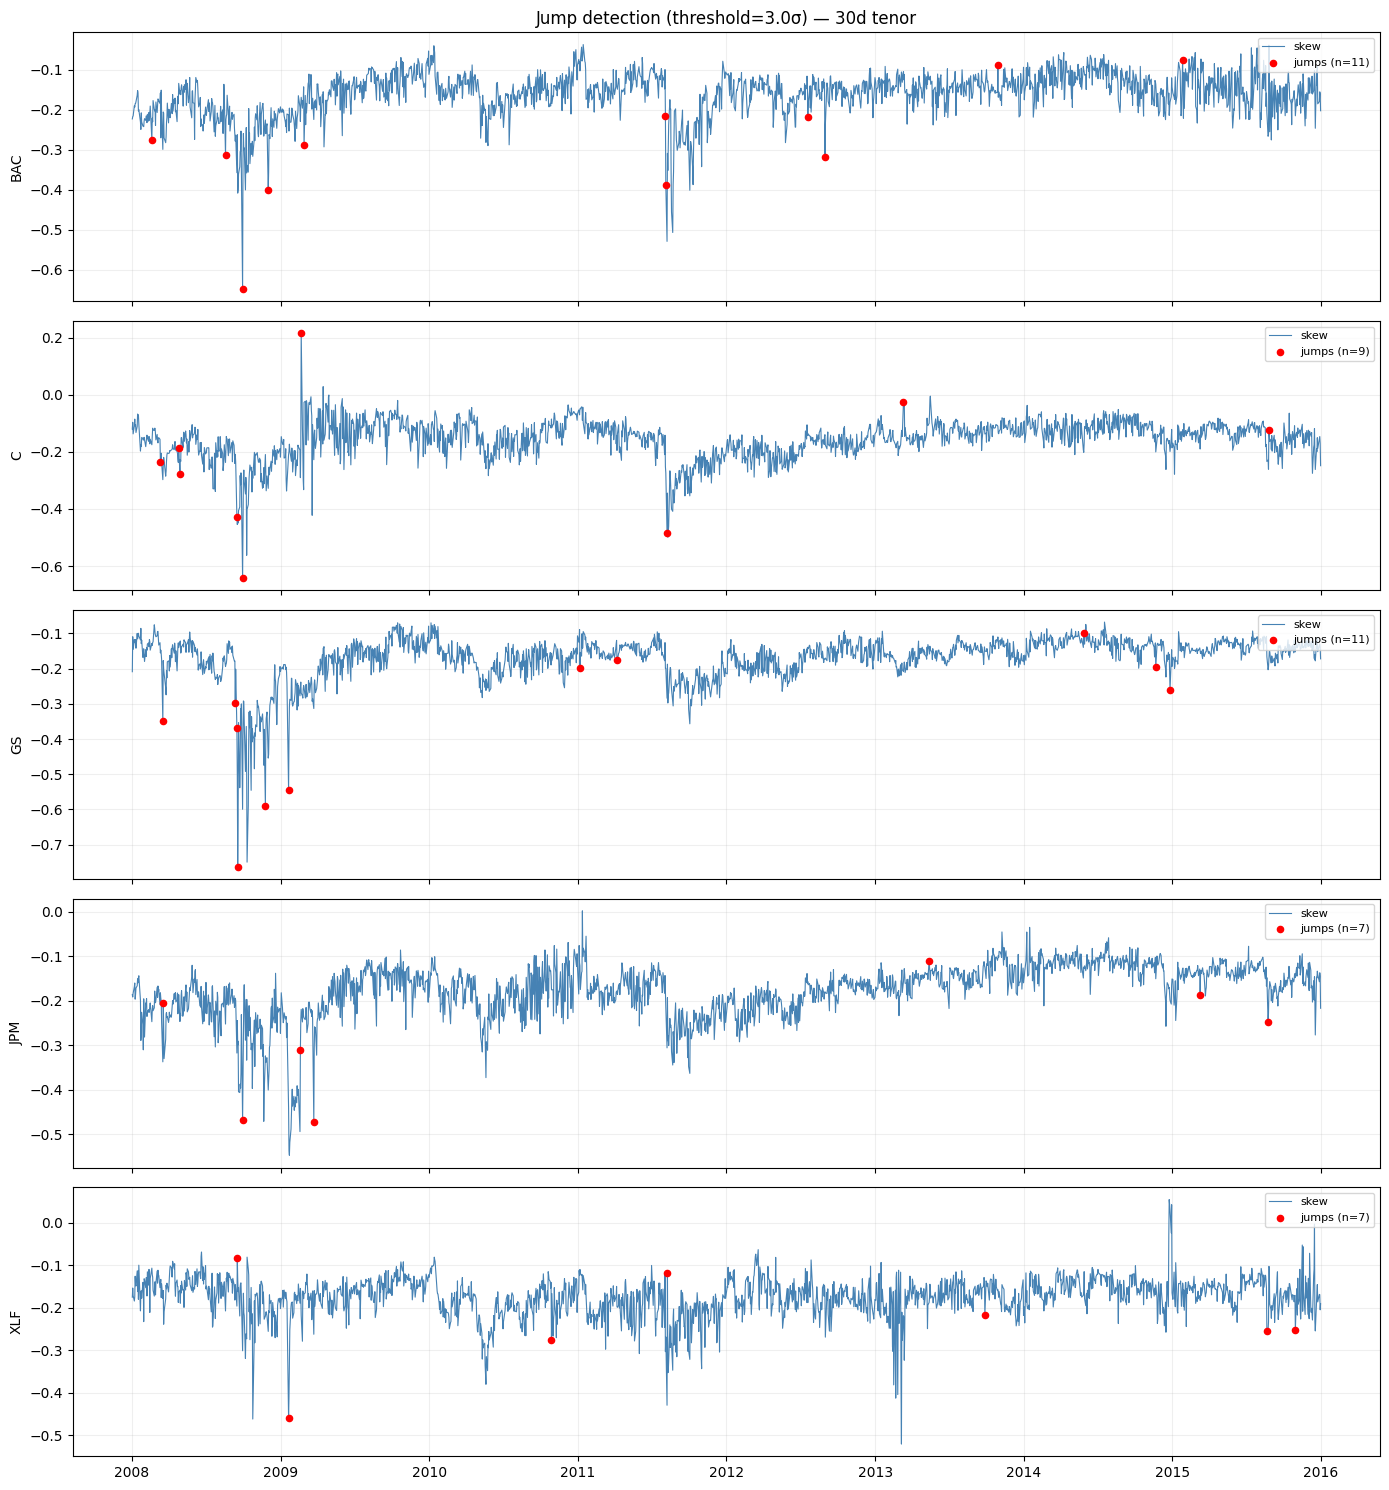

In [8]:
JUMP_THRESHOLD = 3.0   # σ multiples — tweak this
ROLL_WINDOW    = 20    # days for rolling σ estimate

td_plot = tenors[0]
sub = skew_df[skew_df["tenor_days"] == td_plot] if td_plot else skew_df

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 3 * len(tickers)), sharex=True)
if len(tickers) == 1:
    axes = [axes]

print(f"{'ticker':<6}  {'n_jumps':>8} {'jump_rate':>10} {'jump_mean':>10} {'jump_std':>10}  {'diff kurt':>10}  {'diff JB p':>10}")
print("-" * 80)

all_jumps = {}
for ax, ticker in zip(axes, tickers):
    g = sub[sub["ticker"] == ticker].sort_values("date").reset_index(drop=True)
    s  = g["skew"].to_numpy(dtype=np.float64)
    ds = pd.Series(np.concatenate([[np.nan], np.diff(s)]))

    roll_std = ds.rolling(ROLL_WINDOW, min_periods=5).std()
    is_jump  = ds.abs() > JUMP_THRESHOLD * roll_std

    jump_moves = ds[is_jump].dropna()
    diff_moves = ds[~is_jump].dropna()

    diff_kurt = float(stats.kurtosis(diff_moves, fisher=True)) if len(diff_moves) > 4 else np.nan
    _, diff_jb_p = stats.jarque_bera(diff_moves) if len(diff_moves) > 4 else (np.nan, np.nan)

    jump_rate = is_jump.mean()
    all_jumps[ticker] = g["date"][is_jump].tolist()
    print(f"{ticker:<6}  {is_jump.sum():>8} {jump_rate:>10.3f} {jump_moves.mean():>10.4f} {jump_moves.std():>10.4f}  {diff_kurt:>10.2f}  {diff_jb_p:>10.4f}")

    # Plot skew with jumps highlighted
    ax.plot(g["date"], s, linewidth=0.8, color="steelblue", label="skew")
    jump_dates = g["date"][is_jump.values]
    jump_vals  = g["skew"][is_jump.values]
    ax.scatter(jump_dates, jump_vals, color="red", s=20, zorder=5, label=f"jumps (n={is_jump.sum()})")
    ax.set_ylabel(ticker)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.2)

axes[0].set_title(f"Jump detection (threshold={JUMP_THRESHOLD}σ) — {td_plot}d tenor")
plt.tight_layout()
plt.show()

## Step 6: Cross-sectional jump overlap

Are jumps idiosyncratic (single ticker) or systematic (multiple tickers move together)?  
Systematic jumps = macro event. Idiosyncratic jumps = the tradeable signal.

Total jump events:       45
Systematic (≥2 tickers): 3 days, 7 jump events
Idiosyncratic:           38 jump events

Days where ≥2 tickers jumped simultaneously:
2008-09-15    2
2008-09-29    3
2009-01-20    2


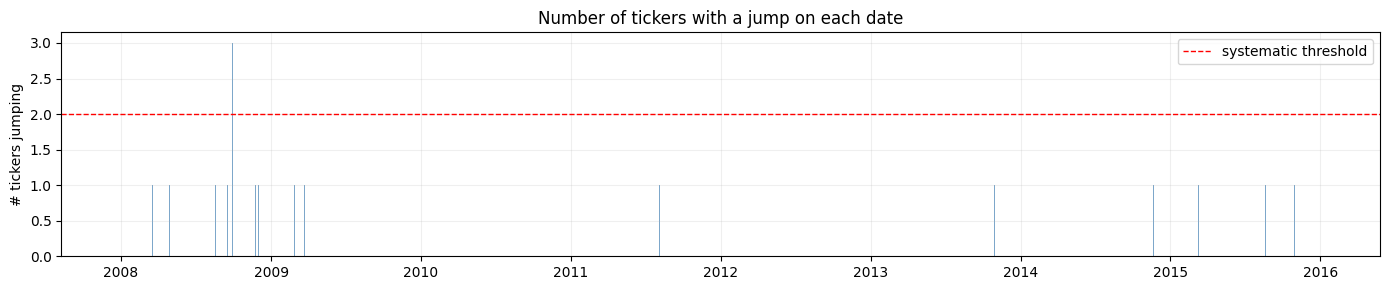

In [9]:
# Build a daily indicator: how many tickers had a jump on each date?
all_dates = sorted(skew_df["date"].unique())
jump_counts = pd.Series(0, index=pd.DatetimeIndex(all_dates))
for ticker, dates in all_jumps.items():
    for d in dates:
        if d in jump_counts.index:
            jump_counts[d] += 1

systematic = jump_counts[jump_counts >= 2]   # 2+ tickers jump on the same day
idiosyncratic_total = sum(len(v) for v in all_jumps.values()) - systematic.sum()

print(f"Total jump events:       {sum(len(v) for v in all_jumps.values())}")
print(f"Systematic (≥2 tickers): {len(systematic)} days, {systematic.sum()} jump events")
print(f"Idiosyncratic:           {idiosyncratic_total} jump events")
print()
print("Days where ≥2 tickers jumped simultaneously:")
print(systematic[systematic > 0].sort_index().to_string())

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(jump_counts.index, jump_counts.values, width=1, color="steelblue", alpha=0.7)
ax.axhline(2, color="red", linewidth=1, linestyle="--", label="systematic threshold")
ax.set_title("Number of tickers with a jump on each date")
ax.set_ylabel("# tickers jumping")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:

from pipeline import Pipeline, MasterRunSpec, DataSpec, VolatilityModelSpec, SkewSpec
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

cfg = MasterRunSpec(
    data=DataSpec(
        tickers=["XLF", "GS", "JPM", "BAC", "C"],
        start_date="2008-01-01",
        end_date="2015-12-31",
    ),
    model=VolatilityModelSpec(model_kind="surface"),
    skew=SkewSpec(technique="rr_approx", rr_k=0.15, tenor_days=[30, 60, 90]),
)

p = Pipeline(cfg)
print("Pipeline built OK")


Pipeline built OK


In [11]:

loaded    = p.run_load(saved="basics.parquet")
processed = p.run_process(loaded, saved="basics.parquet")
modeled   = p.run_model(processed, saved="basics.parquet")
skew      = p.run_skew(modeled, saved="basics_skew.parquet")
print("Pipeline stages complete")
print(f"Tickers in skew: {list(skew.skew_by_ticker.keys())}")
sample = next(iter(skew.skew_by_ticker.values()))
print(f"Skew df shape: {sample.shape}, columns: {list(sample.columns)}")
print(sample.head(6))


Pipeline stages complete
Tickers in skew: ['XLF', 'GS', 'JPM', 'BAC', 'C']
Skew df shape: (13053, 10), columns: ['date', 'ticker', 'tenor_days', 'target_t', 'skew', 'n_points', 'rmse_implied_volatility', 'technique', 'k0', 'model_family']
        date ticker  tenor_days  target_t      skew  n_points  \
0 2008-01-02    XLF          30  0.082192 -0.175701     208.0   
1 2008-01-02    XLF          60  0.164384 -0.135284     208.0   
2 2008-01-02    XLF          90  0.246575 -0.116537     208.0   
3 2008-01-03    XLF          30  0.082192 -0.154065     208.0   
4 2008-01-03    XLF          60  0.164384 -0.121069     208.0   
5 2008-01-03    XLF          90  0.246575 -0.107127     208.0   

   rmse_implied_volatility  technique   k0  model_family  
0                 0.057058  rr_approx  0.0  ssvi_surface  
1                 0.057058  rr_approx  0.0  ssvi_surface  
2                 0.057058  rr_approx  0.0  ssvi_surface  
3                 0.066649  rr_approx  0.0  ssvi_surface  
4         

In [12]:

# Stack into tidy df
parts = []
for ticker, df in skew.skew_by_ticker.items():
    if df is None or df.empty:
        continue
    x = df.copy()
    x["ticker"] = ticker
    x["date"] = pd.to_datetime(x["date"])
    parts.append(x)
skew_df = pd.concat(parts, ignore_index=True).sort_values(["ticker", "tenor_days", "date"]).reset_index(drop=True)

tenors  = sorted(skew_df["tenor_days"].unique().tolist())
tickers = sorted(skew_df["ticker"].unique().tolist())

# Summary stats per ticker/tenor
print("=== Skew summary stats ===")
print(f"{'ticker':<6} {'tenor':>6}  {'mean':>8} {'std':>8} {'min':>8} {'max':>8}  {'n_dates':>8}")
print("-" * 65)
for ticker in tickers:
    for td in tenors:
        sub = skew_df[(skew_df["ticker"]==ticker) & (skew_df["tenor_days"]==td)]
        s = sub["skew"].dropna()
        print(f"{ticker:<6} {td:>6}  {s.mean():>8.4f} {s.std():>8.4f} {s.min():>8.4f} {s.max():>8.4f}  {len(s):>8}")
    print()


=== Skew summary stats ===
ticker  tenor      mean      std      min      max   n_dates
-----------------------------------------------------------------
BAC        30   -0.1481   0.0481  -0.6486  -0.0218      4360
BAC        60   -0.1122   0.0347  -0.4570  -0.0161      4360
BAC        90   -0.0945   0.0288  -0.3536  -0.0133      4360

C          30   -0.1449   0.0537  -0.6410   0.2152      4358
C          60   -0.1123   0.0388  -0.5059   0.1483      4358
C          90   -0.0951   0.0324  -0.3647   0.1187      4358

GS         30   -0.1511   0.0537  -0.7624   0.0556      4360
GS         60   -0.1185   0.0385  -0.4899   0.0422      4360
GS         90   -0.1014   0.0315  -0.3797   0.0356      4360

JPM        30   -0.1600   0.0509  -0.5468   0.0105      4360
JPM        60   -0.1260   0.0386  -0.4408   0.0094      4360
JPM        90   -0.1078   0.0325  -0.4289   0.0077      4360

XLF        30   -0.1656   0.0457  -0.7939   0.1068      4351
XLF        60   -0.1271   0.0331  -0.5613   0.075

In [13]:

from statsmodels.tsa.stattools import adfuller, kpss

def hurst(series, max_lag=40):
    lags = range(2, min(max_lag, len(series) // 2))
    rs = []
    for lag in lags:
        chunks = [series[i:i+lag] for i in range(0, len(series) - lag, lag)]
        rs_vals = []
        for c in chunks:
            c = c - c.mean()
            cs = np.cumsum(c)
            r = cs.max() - cs.min()
            s = c.std()
            if s > 1e-12:
                rs_vals.append(r / s)
        if rs_vals:
            rs.append(np.mean(rs_vals))
    if len(rs) < 2:
        return np.nan
    h, _ = np.polyfit(np.log(list(lags)[:len(rs)]), np.log(rs), 1)
    return float(h)

print(f"{'ticker':<6} {'tenor':>6}  {'ADF p':>8}  {'KPSS p':>8}  {'Hurst':>7}  verdict")
print("-" * 65)
for td in tenors:
    for ticker in tickers:
        s = skew_df[(skew_df["ticker"]==ticker) & (skew_df["tenor_days"]==td)].sort_values("date")["skew"].dropna().to_numpy(dtype=np.float64)
        if len(s) < 30:
            continue
        adf_p = adfuller(s, autolag="AIC")[1]
        try:
            kpss_p = kpss(s, regression="c", nlags="auto")[1]
        except Exception:
            kpss_p = np.nan
        h = hurst(s)
        stationary = adf_p < 0.05 and kpss_p > 0.05
        verdict = "✓ stationary" if stationary else ("~ borderline" if adf_p < 0.10 else "✗ non-stationary")
        if h < 0.45:
            verdict += " | mean-reverting"
        print(f"{ticker:<6} {td:>6}  {adf_p:>8.4f}  {kpss_p:>8.4f}  {h:>7.3f}  {verdict}")
    print()


ticker  tenor     ADF p    KPSS p    Hurst  verdict
-----------------------------------------------------------------
BAC        30    0.0000    0.0100    0.775  ~ borderline
C          30    0.0000    0.0100    0.820  ~ borderline
GS         30    0.0001    0.0100    0.845  ~ borderline
JPM        30    0.0000    0.0100    0.828  ~ borderline
XLF        30    0.0000    0.0100    0.806  ~ borderline

BAC        60    0.0000    0.0100    0.777  ~ borderline
C          60    0.0000    0.0172    0.800  ~ borderline
GS         60    0.0001    0.0100    0.825  ~ borderline
JPM        60    0.0000    0.0100    0.806  ~ borderline
XLF        60    0.0000    0.0100    0.785  ~ borderline

BAC        90    0.0000    0.0100    0.783  ~ borderline
C          90    0.0000    0.0325    0.804  ~ borderline
GS         90    0.0002    0.0100    0.817  ~ borderline
JPM        90    0.0000    0.0100    0.814  ~ borderline
XLF        90    0.0000    0.0100    0.775  ~ borderline



In [14]:

from scipy import stats

def fit_ou(series: "np.ndarray"):
    x = series[:-1]
    dx = np.diff(series)
    A = np.column_stack([np.ones(len(x)), x])
    coef, *_ = np.linalg.lstsq(A, dx, rcond=None)
    alpha, beta = coef
    theta = -beta
    mu    = alpha / theta if abs(theta) > 1e-12 else float("nan")
    sigma = float(np.std(dx - A @ coef))
    half_life = np.log(2) / theta if theta > 1e-12 else float("nan")
    return {"theta": theta, "mu": mu, "sigma": sigma, "half_life_days": half_life}

print(f"{'ticker':<6} {'tenor':>6}  {'theta':>8} {'mu':>10} {'sigma':>8} {'half-life (d)':>14}")
print("-" * 62)
for td in tenors:
    for ticker in tickers:
        s = skew_df[(skew_df["ticker"]==ticker) & (skew_df["tenor_days"]==td)].sort_values("date")["skew"].dropna().to_numpy(dtype=float)
        if len(s) < 30:
            continue
        r = fit_ou(s)
        print(f"{ticker:<6} {td:>6}  {r['theta']:>8.5f} {r['mu']:>10.4f} {r['sigma']:>8.5f} {r['half_life_days']:>14.1f}")
    print()


ticker  tenor     theta         mu    sigma  half-life (d)
--------------------------------------------------------------
BAC        30   0.30880    -0.1480  0.03476            2.2
C          30   0.25763    -0.1449  0.03598            2.7
GS         30   0.14520    -0.1511  0.02783            4.8
JPM        30   0.19158    -0.1600  0.02996            3.6
XLF        30   0.40224    -0.1656  0.03662            1.7

BAC        60   0.28425    -0.1122  0.02422            2.4
C          60   0.25556    -0.1123  0.02590            2.7
GS         60   0.14740    -0.1185  0.02011            4.7
JPM        60   0.17549    -0.1260  0.02183            3.9
XLF        60   0.41279    -0.1271  0.02678            1.7

BAC        90   0.26197    -0.0945  0.01943            2.6
C          90   0.24125    -0.0951  0.02109            2.9
GS         90   0.14276    -0.1013  0.01624            4.9
JPM        90   0.16898    -0.1078  0.01807            4.1
XLF        90   0.39963    -0.1079  0.02187       

In [15]:

print(f"{'ticker':<6}  {'level kurt':>11} {'Δskew kurt':>11}  {'JB p':>8}  {'t-dist ν':>9}  interpretation")
print("-" * 80)

td_plot = 30
sub = skew_df[skew_df["tenor_days"] == td_plot]

for ticker in tickers:
    g = sub[sub["ticker"] == ticker].sort_values("date")
    s  = g["skew"].dropna().to_numpy(dtype=float)
    ds = np.diff(s)
    nu, loc, scale = stats.t.fit(ds, floc=0)
    jb_stat, jb_p  = stats.jarque_bera(ds)
    kurt = float(stats.kurtosis(ds, fisher=True))
    interp = "heavy tails" if nu < 10 else ("mild tails" if nu < 30 else "near-Gaussian")
    print(f"{ticker:<6}  {stats.kurtosis(s, fisher=True):>11.2f} {kurt:>11.2f}  {jb_p:>8.4f}  {nu:>9.2f}  {interp}")


ticker   level kurt  Δskew kurt      JB p   t-dist ν  interpretation
--------------------------------------------------------------------------------
BAC            8.14        5.14    0.0000       3.51  heavy tails
C              6.83       10.63    0.0000       3.58  heavy tails
GS            18.07       16.02    0.0000       3.28  heavy tails
JPM            7.17        4.42    0.0000       3.53  heavy tails
XLF           15.03       22.04    0.0000       2.66  heavy tails


In [16]:

JUMP_THRESHOLD = 3.0
ROLL_WINDOW    = 20
td_plot = 30
sub = skew_df[skew_df["tenor_days"] == td_plot]

all_jumps = {}
print(f"{'ticker':<6}  {'n_jumps':>8} {'jump_rate':>10} {'jump_mean':>10} {'jump_std':>10}  {'diff kurt':>10}  {'diff JB p':>10}")
print("-" * 80)

for ticker in tickers:
    g = sub[sub["ticker"] == ticker].sort_values("date").reset_index(drop=True)
    s  = g["skew"].to_numpy(dtype=float)
    ds = pd.Series(np.concatenate([[float("nan")], np.diff(s)]))
    roll_std = ds.rolling(ROLL_WINDOW, min_periods=5).std()
    is_jump  = ds.abs() > JUMP_THRESHOLD * roll_std

    jump_moves = ds[is_jump].dropna()
    diff_moves = ds[~is_jump].dropna()

    diff_kurt = float(stats.kurtosis(diff_moves, fisher=True)) if len(diff_moves) > 4 else float("nan")
    _, diff_jb_p = stats.jarque_bera(diff_moves) if len(diff_moves) > 4 else (float("nan"), float("nan"))

    jump_rate = is_jump.mean()
    all_jumps[ticker] = g["date"][is_jump].tolist()
    print(f"{ticker:<6}  {is_jump.sum():>8} {jump_rate:>10.3f} {jump_moves.mean():>10.4f} {jump_moves.std():>10.4f}  {diff_kurt:>10.2f}  {diff_jb_p:>10.4f}")


ticker   n_jumps  jump_rate  jump_mean   jump_std   diff kurt   diff JB p
--------------------------------------------------------------------------------
BAC           21      0.005    -0.0574     0.1311        4.17      0.0000
C             17      0.004    -0.0303     0.1695        7.87      0.0000
GS            24      0.006    -0.0727     0.1051       13.16      0.0000
JPM           14      0.003    -0.0516     0.1149        3.15      0.0000
XLF           16      0.004     0.0282     0.2196        9.46      0.0000


In [17]:

all_dates = sorted(skew_df["date"].unique())
jump_counts = pd.Series(0, index=pd.DatetimeIndex(all_dates))
for ticker, dates in all_jumps.items():
    for d in dates:
        ts = pd.Timestamp(d)
        if ts in jump_counts.index:
            jump_counts[ts] += 1

systematic = jump_counts[jump_counts >= 2]
total_jumps = sum(len(v) for v in all_jumps.values())
idiosyncratic_total = total_jumps - systematic.sum()

print(f"Total jump events:       {total_jumps}")
print(f"Systematic (≥2 tickers): {len(systematic)} days, {systematic.sum()} jump events")
print(f"Idiosyncratic:           {idiosyncratic_total} jump events")
print()
print("Days where ≥2 tickers jumped simultaneously (top 20):")
print(systematic[systematic > 0].sort_values(ascending=False).head(20).to_string())


Total jump events:       92
Systematic (≥2 tickers): 9 days, 22 jump events
Idiosyncratic:           70 jump events

Days where ≥2 tickers jumped simultaneously (top 20):
2008-09-29    3
2019-12-20    3
2020-03-06    3
2022-08-26    3
2008-09-15    2
2009-01-20    2
2016-09-12    2
2024-10-18    2
2025-04-04    2


In [18]:

# Check if the OLS residual itself is stationary
# This is the key untested assumption in the whole strategy

td = 30
bench = "XLF"
reg_window = 60

bench_series = skew_df[(skew_df["ticker"] == bench) & (skew_df["tenor_days"] == td)].sort_values("date").set_index("date")["skew"]

print("=== OLS Residual stationarity (vs XLF, 30d tenor) ===")
print(f"{'ticker':<6}  {'ADF p':>8}  {'KPSS p':>8}  {'Hurst':>7}  {'OU half-life':>14}  verdict")
print("-" * 70)

for ticker in [t for t in tickers if t != bench]:
    stock_series = skew_df[(skew_df["ticker"] == ticker) & (skew_df["tenor_days"] == td)].sort_values("date").set_index("date")["skew"]
    
    # Align
    df_pair = pd.DataFrame({"stock": stock_series, "bench": bench_series}).dropna().sort_index()
    
    # Rolling OLS residual
    resid_list = []
    for i in range(len(df_pair)):
        hist = df_pair.iloc[max(0, i-reg_window):i]
        if len(hist) < 40:
            resid_list.append(float("nan"))
            continue
        y = hist["stock"].to_numpy(dtype=float)
        x = hist["bench"].to_numpy(dtype=float)
        coef, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(y)), x]), y, rcond=None)
        row = df_pair.iloc[i]
        y_hat = coef[0] + coef[1] * row["bench"]
        resid_list.append(float(row["stock"]) - float(y_hat))
    
    resid = np.array(resid_list)
    resid_clean = resid[np.isfinite(resid)]
    
    adf_p = adfuller(resid_clean, autolag="AIC")[1]
    try:
        kpss_p = kpss(resid_clean, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = float("nan")
    h = hurst(resid_clean)
    r = fit_ou(resid_clean)
    
    stationary = adf_p < 0.05 and kpss_p > 0.05
    verdict = "✓ stationary" if stationary else ("~ borderline" if adf_p < 0.10 else "✗ non-stationary")
    if h < 0.45:
        verdict += " | mean-reverting"
    print(f"{ticker:<6}  {adf_p:>8.4f}  {kpss_p:>8.4f}  {h:>7.3f}  {r['half_life_days']:>14.1f}  {verdict}")


=== OLS Residual stationarity (vs XLF, 30d tenor) ===
ticker     ADF p    KPSS p    Hurst    OU half-life  verdict
----------------------------------------------------------------------
BAC       0.0000    0.1000    0.772             1.2  ✓ stationary
C         0.0000    0.1000    0.805             1.4  ✓ stationary
GS        0.0000    0.1000    0.830             1.8  ✓ stationary
JPM       0.0000    0.1000    0.802             1.6  ✓ stationary
